## Chemin
*  1 Load the Breast Cancer METABRIC.csv
* 2 Clean the Dataset
* 3 Explore the Dataset (Univariate analysis(pair plot, scatter, boxplot) and Multivariate analysis(corelation (heatmap)))
* 4 Split the Dataset into Train and Test (data.sample, drop ...) => Train_set and Test_set
* 5 Check Dataset Statistics (describe, statical test and one)
* 6 Split the Features from Target Values (pop ..) => X(feature) and Y(label)* 7 Normalize the Feature Data (numerical (min_max, std_scaler), categorical (one-hot, ...))
* 8 Test many model and Choose the best model
* 9 Evaluate with the best metric and explain your result

  1 Load the Breast Cancer METABRIC.csv
  

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sklearn.inspection import permutation_importance
from utils import SurvivalModelWrapper, km_by_group

# Lecture du dataset et mise en forme

In [2]:
df_raw = pd.read_csv('projet.csv', 
    na_values="?",        # Treat '?' as missing values (NaN).
    comment="\t",         # Lines starting with tab ("\t") are comments. Ignore.
    sep=",",              # Use comma as a separator.
    skipinitialspace=True,# Skip initial spaces in the data.
)

 2 Clean the Dataset

In [3]:
# Après analyses ses donnée ne sont pas itiles pour la prédiction car peuvent causer des bias
exculde_features = ["patient_id", "patient's_vital_status", "cancer_type_detailed", "cancer_type", "oncotree_code", 
                    "3-gene_classifier_subtype", "primary_tumor_laterality", "sex", "hormone_therapy", "mutation_count"]


#hormone_therapy ou er_status_measured_by_ihc
categorical_features = ["type_of_breast_surgery", "chemotherapy", "pam50_+_claudin-low_subtype", "er_status_measured_by_ihc", "her2_status_measured_by_snp6", 
                    "inferred_menopausal_state", "integrative_cluster",  "pr_status", "radio_therapy"]

ordinal_features = {"neoplasm_histologic_grade": [1., 2., 3.], 
                    "tumor_stage": [0., 1., 2., 3., 4. ], 
                    "cellularity": ['Low','Moderate','High']
                    }

numerical_features = ["nottingham_prognostic_index", "lymph_nodes_examined_positive", "age_at_diagnosis"]

In [4]:
rsf_model = RandomSurvivalForest(
    n_estimators=400,
    min_samples_split=500,
    min_samples_leaf=250,
    random_state=42
)

gsf_model = GradientBoostingSurvivalAnalysis(
    n_estimators= 200,
    min_samples_split = 400,
    min_samples_leaf = 250,
)

cox_model = CoxPHSurvivalAnalysis(
    alpha=1, 
    ties="efron"
)

## Model tous les variables

In [5]:
# Créer ton wrapper
cox = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

gsf = SurvivalModelWrapper(
    data=df_raw,
    model=gsf_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

rsf = SurvivalModelWrapper(
    data=df_raw,
    model=rsf_model,
    numerical_features=numerical_features,
    categorical_features=categorical_features,
    ordinal_features=ordinal_features,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

In [9]:
cox.get_pipeline()

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['type_of_breast_surgery',
                                                   'chemotherapy',
                                                   'pam50_+_claudin-low_subtype',
                                                   'er_status_measured_by_ihc',
                                                   'her2_status_measured_by_snp6',
                                                   'inferred...
                                                                                               3.0,
                                                                                               4.0],
                                                                                              ['Low',
                                                                                               'Moderate',
                                                                                               'High']]))]),
                                                  ['neoplasm_histologic_grade',
                                                   'tumor_stage',
                                                   'cellularity']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['nottingham_prognostic_index',
                                                   'lymph_nodes_examined_positive',
                                                   'age_at_diagnosis'])])),
                ('survival_model',
                 CoxPHSurvivalAnalysis(alpha=1, ties='efron'))])

In [6]:
# 6. Entraîner
X_test, y_test_surv = cox.fit()
X_test, y_test_surv = rsf.fit()
X_test, y_test_surv = gsf.fit()

# 7. Afficher le C-index
print("C-index_cox:", cox.c_index_)
print("C-index_gsf:", gsf.c_index_)
print("C-index_rsf:", rsf.c_index_)

C-index_cox: 0.6544874583152095
C-index_gsf: 0.6403146295490794
C-index_rsf: 0.6733724807887488


In [10]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

cox.tune_parameters(param_grid, event_col="event", duration_col="duration", cv=5)

Meilleurs paramètres : {'survival_model__alpha': 1.0, 'survival_model__ties': 'efron'}


{'survival_model__alpha': 1.0, 'survival_model__ties': 'efron'}

In [7]:
cv_scores = cox.evaluate_with_cv(cv=5)

--- Résultats de la Validation Croisée (5 folds) ---
C-index moyen : 0.6742
Écart-type     : 0.0426
Scores par fold : [0.75645566 0.64242632 0.64431992 0.65369034 0.67415193]


In [8]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)

result_1 = permutation_importance(
    rsf.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf.get_pipeline(), # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )


In [10]:
# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": cox.get_feature()[0],
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)
perm_df.head()

,feature,importance_cox,importance_rsf,importance_gsf
11,age_at_diagnosis,0.069262,0.042566,0.038205
5,inferred_menopausal_state,0.026200,-0.002371,0.000000
1,chemotherapy,0.019088,0.000000,0.003164
9,nottingham_prognostic_index,0.015623,0.049913,0.034809
10,lymph_nodes_examined_positive,0.007902,0.015811,0.015333


In [11]:
df_test = pd.concat(
    [X_test.reset_index(drop=True), 
    pd.DataFrame(y_test_surv).reset_index(drop=True)],
    axis=1
)


===== Kaplan-Meier : inferred_menopausal_state =====


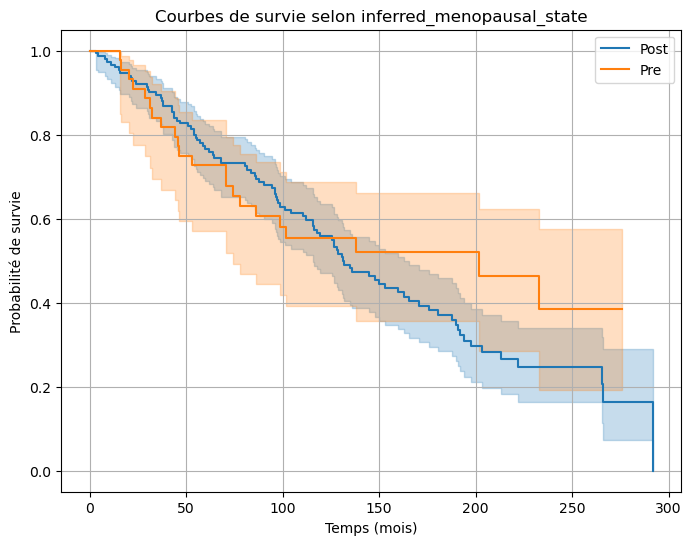


Log-rank test :
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.91 0.34      1.56


In [12]:
km_by_group(df_test, "duration",  "event", "inferred_menopausal_state")

## Predicton


| Ce que tu veux obtenir | Méthode dans `CoxPHSurvivalAnalysis` | Commentaire |
|------------------------|-------------------------------------|-------------|
| Score linéaire $\beta X$ | `model.predict(X)` | C’est le *risk score* non exponentié |
| Risque relatif $\exp(\beta X)$ | `model.predict(X, return_array=True)` puis `np.exp(...)` | *scikit-survival* ne fournit pas `predict_partial_hazard()` |
| Fonction de survie individuelle | `model.predict_survival_function(X)` | Renvoie une liste de courbes de survie |
| Risque cumulé | `model.predict_cumulative_hazard_function(X)` | Renvoie une liste de fonctions de risque cumulé |


In [20]:
pipline = cox.get_pipeline()
# Score linéaire
linear_score = pipline.predict(X_test)

# Risque relatif
partial_hazard = np.exp(linear_score)

# Courbes de survie
surv_funcs = pipline.predict_survival_function(X_test)

# Risque cumulé
cumhaz_funcs = pipline.predict_cumulative_hazard_function(X_test)

### Modèle 1 — Clinique pur (baseline model)

👉 Objectif : référence clinique, forte interprétabilité, faible biais.

In [ ]:
# âge + stade + grade + NPI + ganglions

categorical_features_clinical = []

numerical_features_clinical = [
    "age_at_diagnosis",
    "nottingham_prognostic_index",
    "lymph_nodes_examined_positive"
]

ordinal_features_clinical = {
    "tumor_stage": [0., 1., 2., 3., 4.],
    "neoplasm_histologic_grade": [1., 2., 3.]
}

# Créer ton wrapper
cox = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features_clinical,
    categorical_features=categorical_features_clinical,
    ordinal_features=ordinal_features_clinical,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

cox = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features_clinical,
    categorical_features=categorical_features_clinical,
    ordinal_features=ordinal_features_clinical,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

cox = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features_clinical,
    categorical_features=categorical_features_clinical,
    ordinal_features=ordinal_features_clinical,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

# Entraînement
X_test, y_test_surv = gsf_model.fit(df)
print(f"Modèle GradientBoostingSurvivalAnalysis. C-Index : {gsf_model_cat.c_index_:.4f}")

# Entraînement
X_test, y_test_surv = rsf_model_cat.fit(df)
print(f"Modèle RandomSurvivalForest. C-Index : {rsf_model_cat.c_index_:.4f}")

# 6. Entraîner
X_test, y_test_surv = wrapper.fit()

# 7. Afficher le C-index
print("C-index:", wrapper.c_index_)

C-index: 0.6126576772509786


In [ ]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)


result_1 = permutation_importance(
    rsf_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf_model_cat.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": new_cat_columns,
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)

perm_df.head()

🧬 Modèle 2 — Moléculaire pur

👉 Objectif : mesurer la valeur ajoutée biologique indépendante du clinique.

In [14]:
categorical_features_molecular = [
    "pam50_+_claudin-low_subtype",
    "er_status_measured_by_ihc",
    "pr_status",
    "her2_status_measured_by_snp6",
    "integrative_cluster"
]

numerical_features_mixed = [
    "age_at_diagnosis",
]
ordinal_features_molecular = {}

# Créer ton wrapper
wrapper = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features_molecular,
    categorical_features=categorical_features_molecular,
    ordinal_features=ordinal_features_molecular,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

# 6. Entraîner
X_test, y_test_surv = wrapper.fit()

# 7. Afficher le C-index
print("C-index:", wrapper.c_index_)

TypeError: Sparse data was passed for X, but dense data is required. Use '.toarray()' to convert to a dense numpy array.

## Modèle 3 — Mixte (clinique + moléculaire)

👉 Objectif : meilleure performance prédictive sans redondance excessive.

In [13]:
numerical_features_mixed = [
    "age_at_diagnosis",
    "lymph_nodes_examined_positive"
]

ordinal_features_mixed = {
    "tumor_stage": [0., 1., 2., 3., 4.]
}

categorical_features_mixed = [
    "pam50_+_claudin-low_subtype",
    "er_status_measured_by_ihc",
    "her2_status_measured_by_snp6"
]

# Créer ton wrapper
wrapper = SurvivalModelWrapper(
    data=df_raw,
    model=cox_model,
    numerical_features=numerical_features_mixed,
    categorical_features=categorical_features_mixed,
    ordinal_features=ordinal_features_mixed,
    exclude_cols= exculde_features,   # si tu veux
    global_survie=True
)

# 6. Entraîner
X_test, y_test_surv = wrapper.fit()

# 7. Afficher le C-index
print("C-index:", wrapper.c_index_)

C-index: 0.6259243149195303


In [ ]:
# Cross validation pour tuning des hyperparamètres
param_grid = {
    "survival_model__alpha": [0.001, 0.01, 0.1, 0.5, 1.0],
    "survival_model__ties": ["breslow", "efron"]
}

cox_model.tune_parameters(param_grid, event_col="event", duration_col="duration", cv=5)

# Entraînement
X_test, y_test_surv = cox_model.fit(df)
print(f"Modèle entraîné. C-Index : {cox_model.c_index_:.4f}")


Meilleurs paramètres : {'survival_model__alpha': 0.5, 'survival_model__ties': 'efron'}
Modèle entraîné. C-Index : 0.6129


In [ ]:
# Entraînement
X_test, y_test_surv = gsf_model.fit(df)
print(f"Modèle GradientBoostingSurvivalAnalysis. C-Index : {gsf_model.c_index_:.4f}")

# Entraînement
X_test, y_test_surv = rsf_model.fit(df)
print(f"Modèle RandomSurvivalForest. C-Index : {rsf_model.c_index_:.4f}")

Modèle GradientBoostingSurvivalAnalysis. C-Index : 0.6229
Modèle RandomSurvivalForest. C-Index : 0.6484


In [19]:
# Attention : cela peut être lent sur de gros datasets
result_0 = permutation_importance(
    cox_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42)


result_1 = permutation_importance(
    rsf_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

result_2 = permutation_importance(
    gsf_model.pipeline, # et non model.model
    X_test, 
    y_test_surv, 
    n_repeats=10, random_state=42 )

# Affichage des résultats globaux
perm_df = pd.DataFrame({
    "feature": num_feature,
    "importance_cox": result_0.importances_mean,
    "importance_rsf": result_1.importances_mean,
    "importance_gsf": result_2.importances_mean
}).sort_values(by="importance_cox", ascending=False)

perm_df.head()

,feature,importance_cox,importance_rsf,importance_gsf
4,Age at Diagnosis,0.030767,0.060954,0.041779
2,Nottingham prognostic index,0.026975,0.036462,0.032018
3,Tumor Size,0.012121,0.007206,0.007485
1,Lymph nodes examined positive,0.009229,0.006626,0.014985
0,Tumor Stage,0.009069,0.004966,-0.003694


# Verifier la qualitée des données

In [ ]:
print(f"\nC-index sur l'ensemble de test: {c_index:.3f}")

# Tracer les courbes de survie pour différents profils de risque
from lifelines import KaplanMeierFitter

# Calculer les scores de risque
risk_scores = cph.predict_partial_hazard(df_clean[features])
df_clean['risk_score'] = risk_scores

# Créer des groupes de risque
df_clean['risk_group'] = pd.qcut(df_clean['risk_score'], q=3, labels=['Low', 'Medium', 'High'])

# Tracer les courbes de survie pour chaque groupe de risque
kmf = KaplanMeierFitter()

plt.figure(figsize=(10, 6))

for group in ['Low', 'Medium', 'High']:
    mask = df_clean['risk_group'] == group
    kmf.fit(df_clean[mask]['duration'],
            df_clean[mask]['event'],
            label=f'{group} Risk')
    kmf.plot()

plt.title('Courbes de survie par groupe de risque')
plt.xlabel('Temps (mois)')
plt.ylabel('Probabilité de survie')
plt.grid(True)
plt.show()


C-index sur l'ensemble de test: 0.622


C:\Users\goudj\AppData\Local\Temp\ipykernel_3788\4262389960.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['risk_score'] = risk_scores
C:\Users\goudj\AppData\Local\Temp\ipykernel_3788\4262389960.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['risk_group'] = pd.qcut(df_clean['risk_score'], q=3, labels=['Low', 'Medium', 'High'])


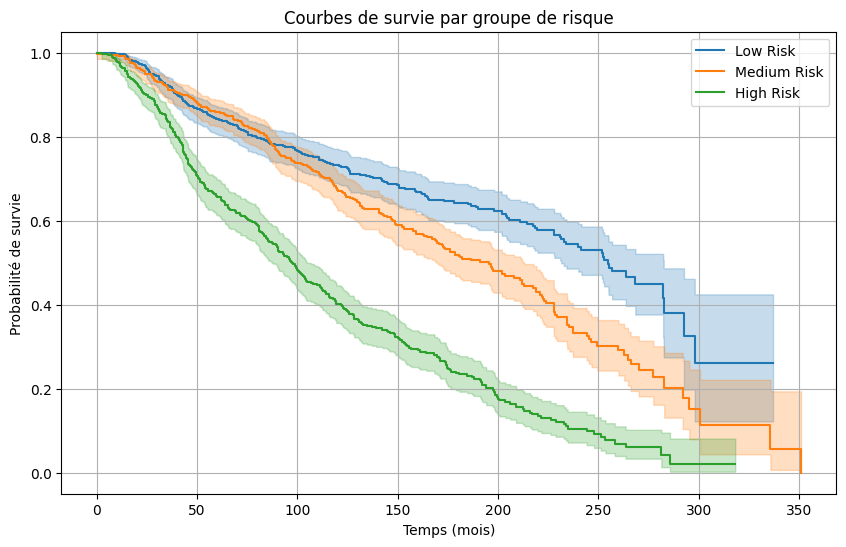

In [100]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for group in ['Low', 'Medium', 'High']:
    mask = df_clean['risk_group'] == group
    kmf.fit(df_clean[mask]['duration'],
            df_clean[mask]['event'],
            label=f'{group} Risk')
    kmf.plot()

plt.title('Courbes de survie par groupe de risque')
plt.xlabel('Temps (mois)')
plt.ylabel('Probabilité de survie')
plt.grid(True)
plt.show()